<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Copy_of_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting House Prices

##Problem Definition

##Data Collection

In [88]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

In [89]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

In [90]:
df = pd.read_csv(url)
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [91]:
#Rows and Columns
df.shape

(2637, 81)

###Columns

####Find Identifier Columns

In [92]:
#Run code to identifier columns
identifier_cols = []

for col in df.columns:
    if df[col].nunique() == len(df):
        identifier_cols.append(col)

print(identifier_cols)

['PID']


In [93]:
#Verify all rows are unique
df['PID'].nunique()

2637

In [94]:
#Must match df['target'].nunique
len(df)

2637

####Verify Target Column doesn't have any nulls

In [95]:
#Rows with nulls in target column
df['PID'].isnull().sum()

np.int64(0)

####Feature columns

In [96]:
#Drop target column
df.drop(columns=['PID'], inplace=True)

In [97]:
#View all columns in a sorted list
# df.columns.sort_values().to_list()

In [98]:
#Rows with nulls in each
df.isnull().sum().sort_values()*1000

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Land Contour,0
...,...
Mas Vnr Type,1607000
Fence,2109000
Alley,2457000
Misc Feature,2541000


####Numerical/Categorical columns

In [99]:
#Look for int, float, object totals at the bottom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2637 non-null   int64  
 1   MS Zoning        2637 non-null   object 
 2   Lot Frontage     2188 non-null   float64
 3   Lot Area         2637 non-null   int64  
 4   Street           2637 non-null   object 
 5   Alley            180 non-null    object 
 6   Lot Shape        2637 non-null   object 
 7   Land Contour     2637 non-null   object 
 8   Utilities        2637 non-null   object 
 9   Lot Config       2637 non-null   object 
 10  Land Slope       2637 non-null   object 
 11  Neighborhood     2637 non-null   object 
 12  Condition 1      2637 non-null   object 
 13  Condition 2      2637 non-null   object 
 14  Bldg Type        2637 non-null   object 
 15  House Style      2637 non-null   object 
 16  Overall Qual     2637 non-null   int64  
 17  Overall Cond  

###Rows

In [100]:
df.isnull().sum().sort_values()

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Land Contour,0
...,...
Mas Vnr Type,1607
Fence,2109
Alley,2457
Misc Feature,2541


In [101]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

In [102]:
#Missing rows
df.isnull().sum().sort_values()

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Land Contour,0
...,...
Mas Vnr Type,1607
Fence,2109
Alley,2457
Misc Feature,2541


### Exploring Features

In [103]:
df['SalePrice'].isna().sum()

np.int64(0)

In [104]:
df['SalePrice'].describe()

,SalePrice
count,2637.000000
mean,179986.230186
std,78309.251522
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213000.000000
max,745000.000000


In [105]:
df.dtypes.value_counts()

,count
object,43
int64,26
float64,11


#### Float Fields

In [106]:
df.select_dtypes(include=['float64'])

,Lot Frontage,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath,Garage Yr Blt,Garage Cars,Garage Area
0,62.0,0.0,513.0,144.0,348.0,1005.0,1.0,0.0,1964.0,2.0,440.0
1,72.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1967.0,2.0,516.0
2,50.0,0.0,0.0,0.0,780.0,780.0,0.0,0.0,1979.0,1.0,544.0
3,68.0,0.0,484.0,0.0,491.0,975.0,1.0,0.0,2000.0,2.0,592.0
4,60.0,0.0,350.0,210.0,0.0,560.0,1.0,0.0,1971.0,2.0,576.0
...,...,...,...,...,...,...,...,...,...,...,...
2632,52.0,0.0,0.0,0.0,816.0,816.0,0.0,0.0,1985.0,2.0,528.0
2633,74.0,0.0,460.0,286.0,308.0,1054.0,1.0,0.0,1990.0,2.0,462.0
2634,61.0,0.0,960.0,0.0,266.0,1226.0,1.0,0.0,1981.0,2.0,484.0
2635,78.0,174.0,0.0,0.0,1064.0,1064.0,0.0,0.0,1974.0,2.0,478.0


#### Int Fields

In [107]:
df_int = df.select_dtypes(include=['int64']).drop(columns=['SalePrice'])
df_int

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,0,7,2007
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,0,500,10,2006
2,50,9000,6,6,1937,1950,780,595,0,1375,...,1,0,162,0,0,126,0,0,12,2007
3,60,7379,8,5,2000,2000,975,873,0,1848,...,1,280,184,0,0,0,0,0,4,2010
4,70,7200,7,9,1936,2007,575,560,0,1135,...,0,256,0,0,0,0,0,0,4,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,1,112,0,0,0,0,0,400,9,2006
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,0,114,36,0,0,0,0,0,7,2009
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,2,133,78,0,0,0,0,0,9,2009
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,1,0,0,0,0,0,0,0,8,2009


In [108]:
# df.select_dtypes(include=['int64']).columns.sort_values().tolist()

In [109]:
df['Lot Area'].isna().sum()

np.int64(0)

In [110]:
df.select_dtypes(include=['int64']).isna().sum().sort_values()

,0
MS SubClass,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
Year Remod/Add,0
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0
Gr Liv Area,0


In [111]:
# df.isna().sum()*1000

#### Object Fields

In [112]:
df.select_dtypes(include=['object'])

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,...,Detchd,Unf,TA,TA,N,NaN,MnPrv,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,...,CarPort,Unf,TA,TA,Y,NaN,NaN,Shed,WD,Normal
2,RM,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,...,Detchd,Unf,TA,TA,P,NaN,NaN,NaN,WD,Normal
3,FV,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,...,Detchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,...,Detchd,Unf,TA,TA,Y,NaN,MnPrv,Shed,WD,Normal
2633,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,SawyerW,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2634,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Greens,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2635,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal


##Data Cleaning

In [114]:
df[['SalePrice', 'Lot Area']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   SalePrice  2637 non-null   int64
 1   Lot Area   2637 non-null   int64
dtypes: int64(2)
memory usage: 41.3 KB


In [116]:
df[['SalePrice', 'Lot Area']].describe()

,SalePrice,Lot Area
count,2637.000000,2637.000000
mean,179986.230186,10044.694729
std,78309.251522,6742.549521
min,12789.000000,1300.000000
25%,129500.000000,7436.000000
50%,160000.000000,9450.000000
75%,213000.000000,11526.000000
max,745000.000000,164660.000000


In [117]:
df[['SalePrice', 'Lot Area']].isnull().sum()

,0
SalePrice,0
Lot Area,0


Imputation

In [ ]:
# drop_cols = df_clean.columns[df_clean.isnull().sum() > 1500]
# drop_cols

In [ ]:
# df_clean = df_clean.drop(columns=drop_cols)
# df_clean

In [81]:
df_clean[col] = df_clean[col].fillna(df_clean[col].median())

##Exploratory Data Analysis (EDA)

In [82]:
cols = ['SalePrice'] + df_int.columns.tolist()
df_lr = df[cols]
df_lr

,SalePrice,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,115400,20,14299,4,3,1964,1964,1005,0,0,...,0,0,0,0,0,0,0,0,7,2007
1,90000,90,10791,4,5,1967,1967,1296,0,0,...,0,0,0,0,0,0,0,500,10,2006
2,141000,50,9000,6,6,1937,1950,780,595,0,...,1,0,162,0,0,126,0,0,12,2007
3,254000,60,7379,8,5,2000,2000,975,873,0,...,1,280,184,0,0,0,0,0,4,2010
4,155000,70,7200,7,9,1936,2007,575,560,0,...,0,256,0,0,0,0,0,0,4,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,114500,50,6240,6,6,1934,1950,816,0,360,...,1,112,0,0,0,0,0,400,9,2006
2633,162000,80,10778,7,6,1990,1991,1061,0,0,...,0,114,36,0,0,0,0,0,7,2009
2634,211500,120,3782,8,5,1981,1981,1226,0,0,...,2,133,78,0,0,0,0,0,9,2009
2635,165000,20,10140,6,5,1974,1974,1350,0,0,...,1,0,0,0,0,0,0,0,8,2009


In [83]:
X = df_clean[['Lot Area']].copy()
y = df_clean['SalePrice'].copy()

###Histogram

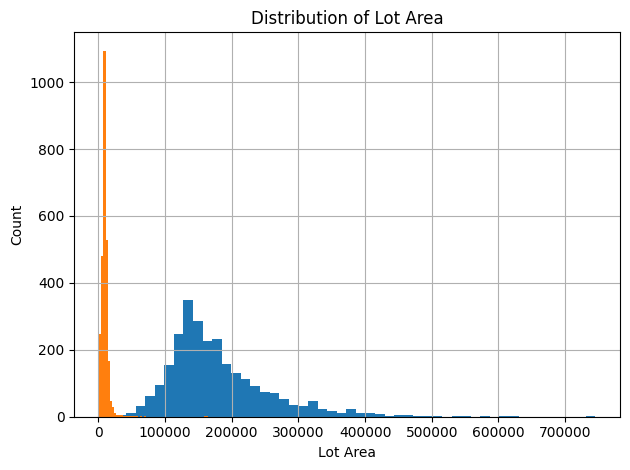

In [129]:
n = int(2637**(1/2))

#SalePrice
df_lr['SalePrice'].hist(bins=n)
plt.xlabel('Sale Price')
plt.ylabel('Count')
plt.title('Distribution of Sale Price')

#LotArea
df['Lot Area'].hist(bins=n)
plt.xlabel('Lot Area')
plt.ylabel('Count')
plt.title('Distribution of Lot Area')

plt.tight_layout()
plt.show()

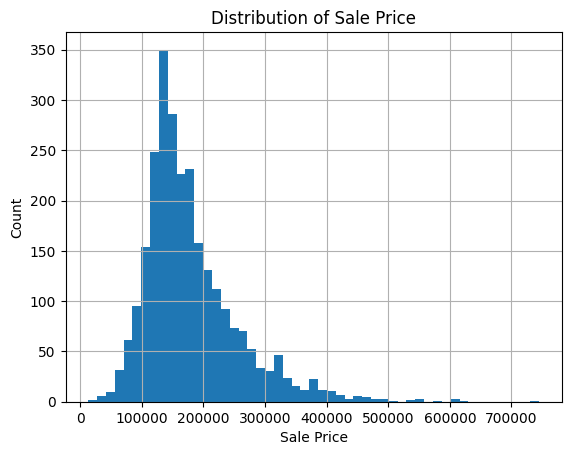

In [119]:
n = int(2637**(1/2))

df_lr['SalePrice'].hist(bins=n)
plt.xlabel('Sale Price')
plt.ylabel('Count')
plt.title('Distribution of Sale Price')
plt.show()

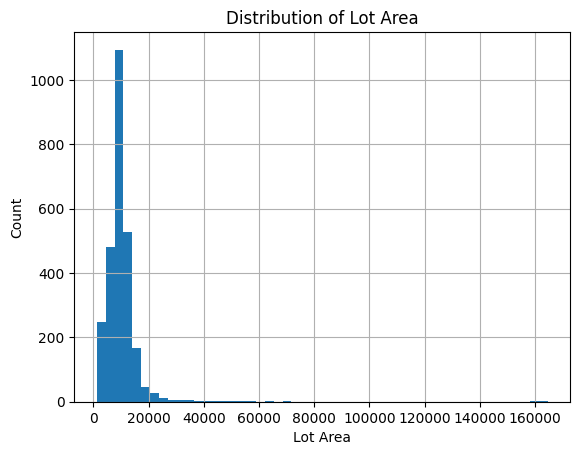

In [121]:
df['Lot Area'].hist(bins=n)
plt.xlabel('Lot Area')
plt.ylabel('Count')
plt.title('Distribution of Lot Area')
plt.show()

###Boxplot

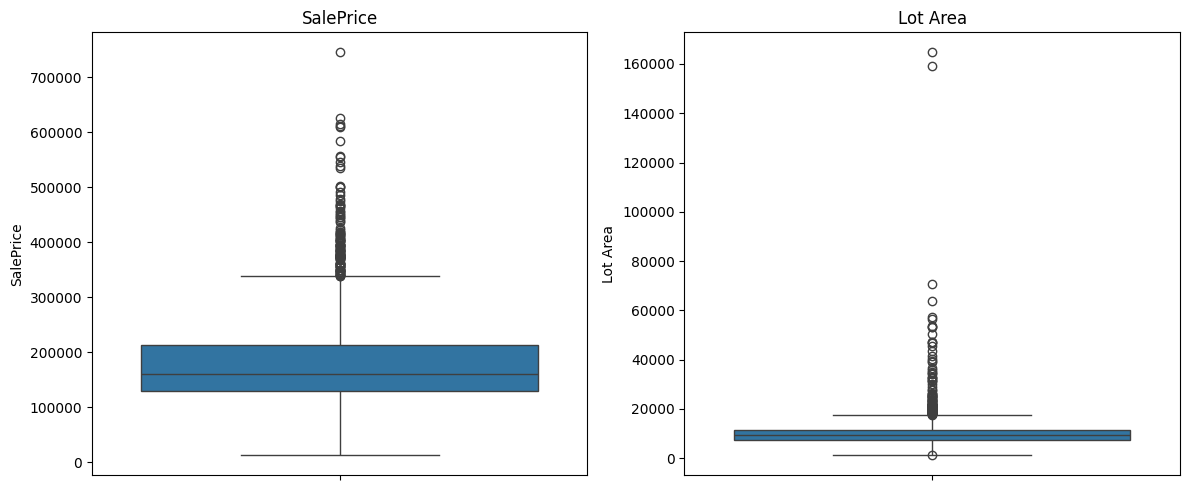

In [123]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#SalePrice
sns.boxplot(y=df_lr["SalePrice"], ax=ax[0])
ax[0].set_title("SalePrice")

#LotArea
sns.boxplot(y=df["Lot Area"], ax=ax[1])
ax[1].set_title("Lot Area")

plt.tight_layout()
plt.show()

###Scatter

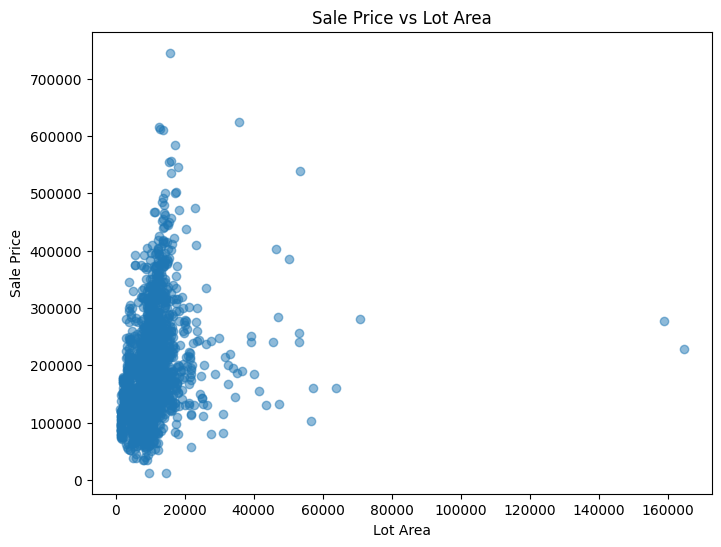

In [124]:
plt.figure(figsize=(8,6))

plt.scatter(df['Lot Area'], df['SalePrice'], alpha=0.5)

plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.title('Sale Price vs Lot Area')

plt.show()

###Correlation

In [126]:
corr = df[['SalePrice','Lot Area']].corr()
corr

,SalePrice,Lot Area
SalePrice,1.000000,0.268516
Lot Area,0.268516,1.000000


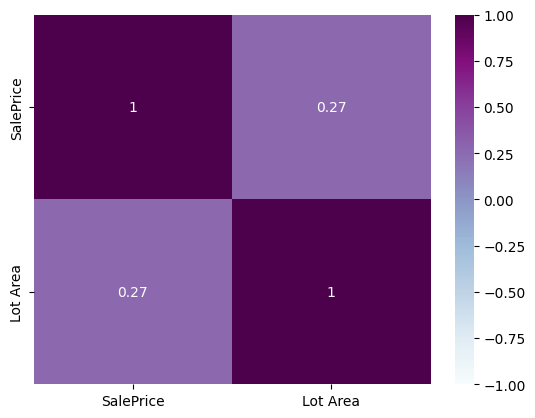

In [127]:
sns.heatmap(
    corr,
    annot=True,
    cmap='BuPu',
    vmin=-1,
    vmax=1
)

plt.show()

In [ ]:
cols = ['SalePrice'] + df_clean.columns.tolist()
df_clean = df[cols]
df_clean

corr_matrix
sns.heatmap(
  corr_matrix,
  cmap='coolwarm',
  xticklabels = df_clean.columns,
  yticklabels = df_clean.columns,
  annot=True,
  vmin = 0,
  vmax = 1,
  )

plt.title("Correlation Heatmap")
plt.savefig('corr.png')
plt.show()

###Box-Cox

<Axes: xlabel='SalePrice', ylabel='Count'>

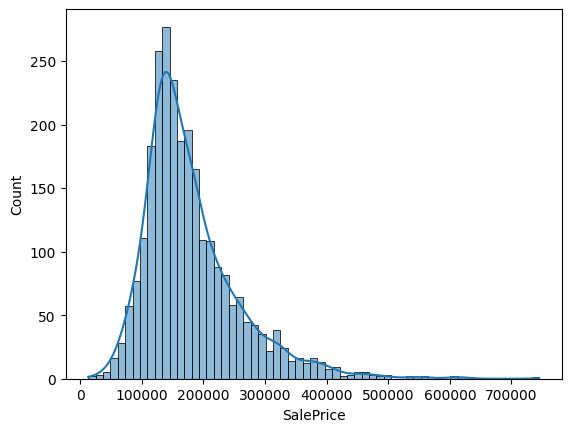

In [130]:
sns.histplot(df['SalePrice'], kde=True)

<Axes: xlabel='Lot Area', ylabel='Count'>

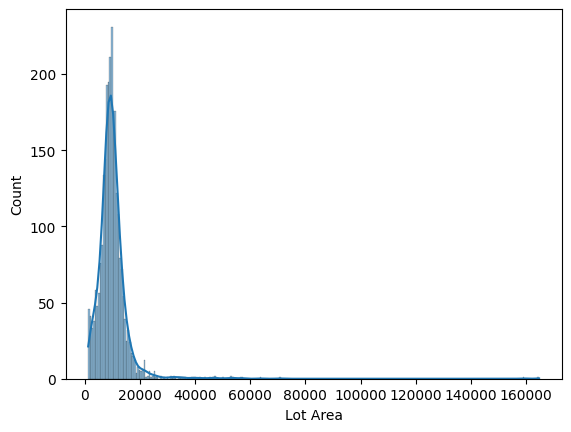

In [132]:
sns.histplot(df['Lot Area'], kde=True)

##Linear Regresssion Model

In [40]:
#First we will break up our data into training and testing sets
# X = df_clean.drop(columns=['SalePrice'])
X = df_lr[['Lot Area']]
y = df_lr['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=4)

In [41]:
model = LinearRegression()

In [42]:
#Fit a linear model using Sklearn
model = LinearRegression()
myfit = model.fit(X_train, y_train)

( myfit.intercept_, myfit.coef_ )

(np.float64(143176.23886589063), array([3.6277113]))

Text(0, 0.5, 'Predicted SalePrice')

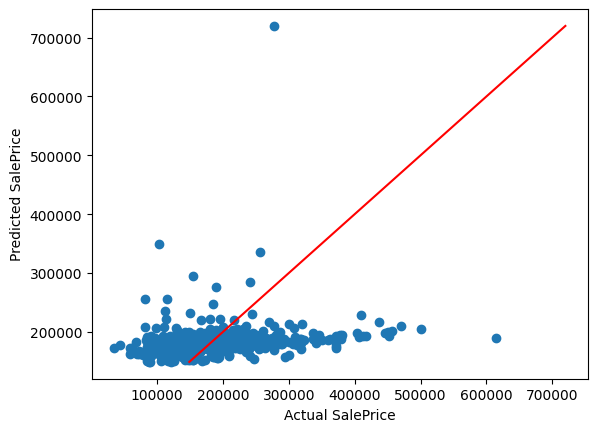

In [43]:
#See how well our model performs on our test data
y_pred = myfit.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='red')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')

IndexError: index 1626 is out of bounds for axis 0 with size 528

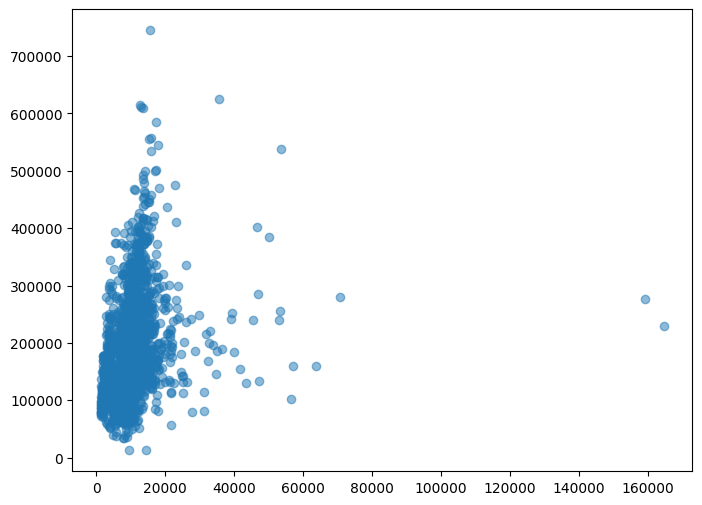

In [133]:
sorted_idx = X['Lot Area'].argsort()

plt.figure(figsize=(8,6))

plt.scatter(X['Lot Area'], y, alpha=0.5)

plt.plot(
    X['Lot Area'].iloc[sorted_idx],
    y_pred[sorted_idx],
    color='red',
    linewidth=3
)

plt.xlabel('Lot Area')
plt.ylabel('Sale Price')
plt.title('Linear Regression')
plt.show()

In [ ]:
# list(zip(y_test,y_pred))[:10]

[(247000, np.float64(179587.57721210603)),
 (135000, np.float64(175825.64059110123)),
 (165000, np.float64(180120.8507736178)),
 (127500, np.float64(157843.07566311577)),
 (105000, np.float64(157541.9756249833)),
 (100000, np.float64(180396.5568326307)),
 (201800, np.float64(192875.88371426673)),
 (235128, np.float64(186462.09013091426)),
 (155000, np.float64(179453.3518939024)),
 (104000, np.float64(163201.2052573531))]

In [ ]:
#Calculate root mean squared error on test data
rmse = mean_squared_error(y_test, y_pred)**0.5
print(f"RMSE: {rmse}")

RMSE: 32663.251161534263


In [ ]:
#Use cross validation to assess model performance
results = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 33904.59602796537


In [ ]:
#Fit a linear model using Sklearn
model = LinearRegression()
myfit = model.fit(X_train, y_train)

( myfit.intercept_, myfit.coef_ )

(np.float64(179615.4914669582), array([24455.38481557]))

Text(0, 0.5, 'Predicted SalePrice')

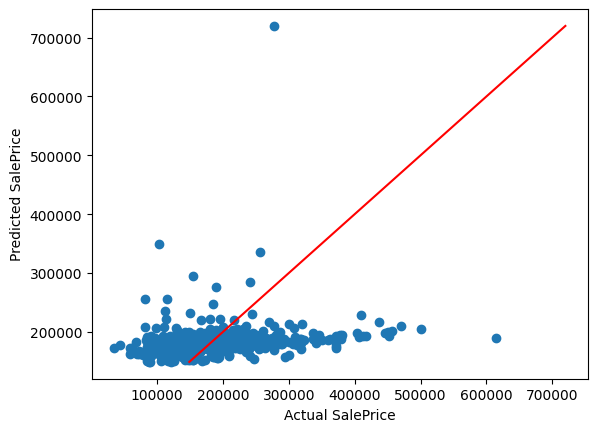

In [ ]:
#See how well our model performs on our test data
y_pred = myfit.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='red')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')

In [ ]:
list(zip(y_test,y_pred))[:10]

[(247000, np.float64(179587.57721210603)),
 (135000, np.float64(175825.64059110123)),
 (165000, np.float64(180120.8507736178)),
 (127500, np.float64(157843.07566311577)),
 (105000, np.float64(157541.9756249833)),
 (100000, np.float64(180396.5568326307)),
 (201800, np.float64(192875.88371426676)),
 (235128, np.float64(186462.09013091426)),
 (155000, np.float64(179453.3518939024)),
 (104000, np.float64(163201.2052573531))]

In [ ]:
#Calculate root mean squared error on test data
rmse = mean_squared_error(y_test, y_pred)**0.5
print(f"RMSE: {rmse}")

RMSE: 78564.26630298985


In [ ]:
#Use cross validation to assess model performance
results = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 75885.63952842879


##PH: Feature Scaling

In [ ]:
#Scale the features using the StandardScaler ( Z-score )
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=4)

In [ ]:
X

,Lot Area
0,14299
1,10791
2,9000
3,7379
4,7200
...,...
2632,6240
2633,10778
2634,3782
2635,10140


In [ ]:
X_scaled

array([[ 0.63108356],
       [ 0.11070691],
       [-0.15497   ],
       ...,
       [-0.92900801],
       [ 0.01413758],
       [ 0.35828634]])

In [ ]:
pd.DataFrame(X_scaled).describe().transpose()

,count,mean,std,min,25%,50%,75%,max
0,2637.0,1.054228e-16,1.00019,-1.297188,-0.386974,-0.088217,0.219737,22.935631


##PH: RMSPE Comparison

##PH: Feature Reduction

##PH: Interpolation vs Extrapolation Discussion

### Residual Analysis

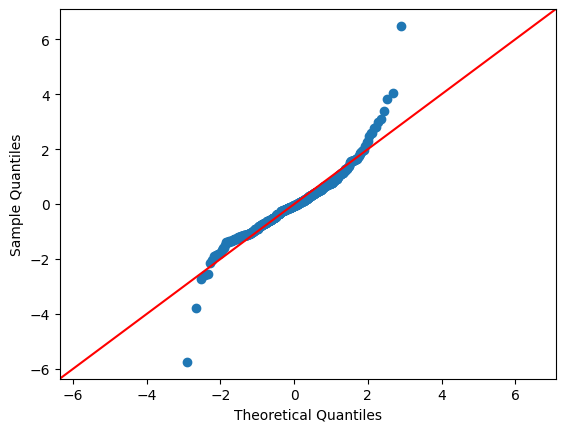

In [ ]:
#QQ Plot - Residuals are normally distributed
res = y_test - y_pred
sm.qqplot(res, fit=True, line="45");

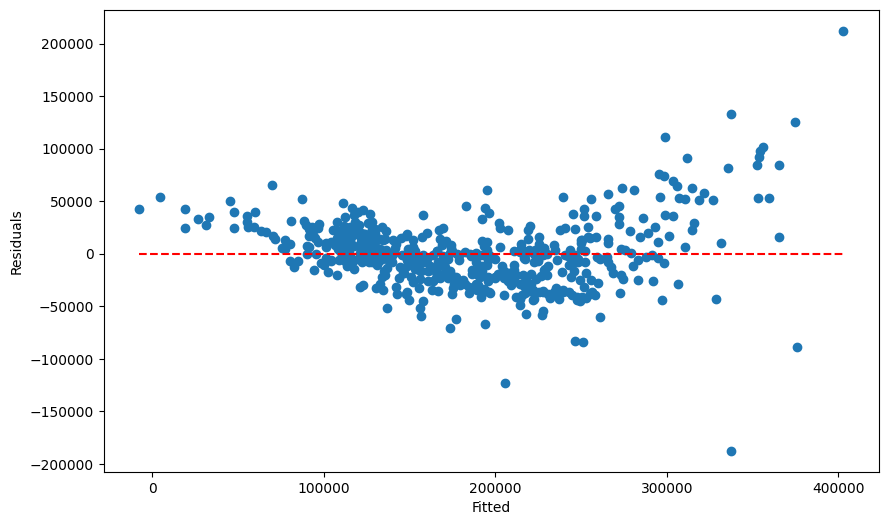

In [ ]:
#Residuals vs Fitted (Predicted) Values - Constant variance
plt.figure(figsize = (10,6))
plt.scatter(y_pred, res)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.hlines(0, min(y_pred), max(y_pred), colors = 'red', linestyles = 'dashed')

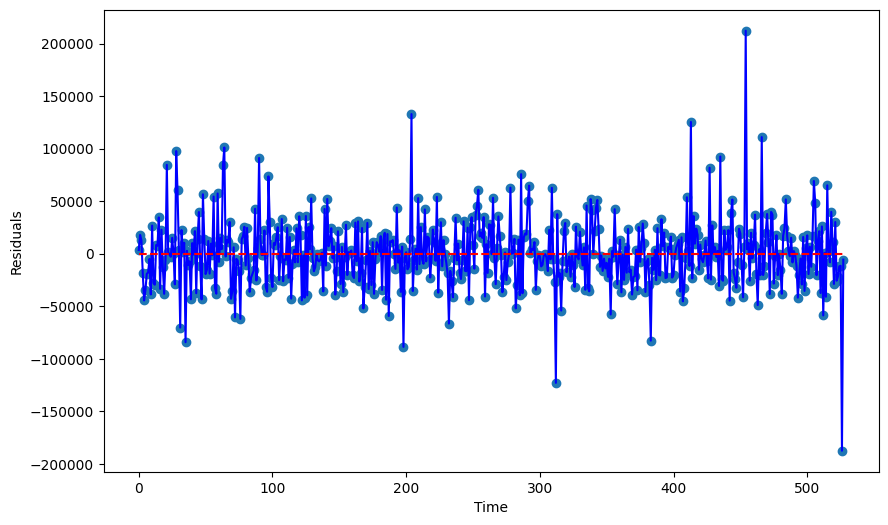

In [ ]:
#Residuals vs Time - indepedence
plt.figure(figsize = (10,6))
plt.scatter(range(len(res)), res)
plt.plot(range(len(res)), res, 'b')
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.hlines(0, min(range(len(res))), max(range(len(res))), colors = 'red', linestyles = 'dashed')

##Data Visualization/Communication of Results